## Cross Entropy Loss Function

Cross Entropy takes the predicted probabilities and the actual y and outputs a value.\
Cross Entropy is mainly used for classification, while SSR is used for regression.

* If the value is high, the model is doing poorly.
* If the value is low/near zero, the model is doing well.

### Contents:
* [Importing Dependencies](#idp)
* [Creating Data](#cdf)
* [Loss Function](#dlf)
* [Using the model](#utm)
* [Visualizing the results](#vtr)

### Importing Dependencies <a id = "idp">

In [12]:
import numpy as np
import matplotlib.pyplot as plt

### Creating the data to input into the function <a id = "cdf">

In [7]:
y_true = np.array([1, 0, 1, 1])

# Case 1: The "Confident & Correct" Model
# This model is very sure about its correct answers.
y_pred_good = np.array([0.95, 0.05, 0.99, 0.90])

# Case B: The "Confused" Model
# This model is guessing near 0.5 or getting things wrong.
y_pred_bad = np.array([0.40, 0.60, 0.10, 0.50])

### Defining the Loss Function <a id = "dlf">

In [8]:
def compute_bce_loss(y_true, y_pred):
    # If the model returns a probability of 0, this will cause C.E. to log(0) which is infinity
    # Hence, we cap the values at a min of (1e-15), and max of (1 - 1e-15)
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    
    # Calculate loss for each individual point
    # C.E. Formula: -(y * log(p) + (1-y) * log(1-p))
    # This formula makes it so each y value only runs one half of the function
    individual_loss = -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    
    # Average the losses
    return np.mean(individual_loss)

### Using the model <a id = "utm">

In [9]:
# Compare the results
loss_good = compute_bce_loss(y_true, y_pred_good)
loss_bad = compute_bce_loss(y_true, y_pred_bad)

print(f"Good Model Loss: {loss_good:.4f}") # Expect a low number (~0.05)
print(f"Bad Model Loss: {loss_bad:.4f}")   # Expect a high number (~1.0+)

Good Model Loss: 0.0545
Bad Model Loss: 1.2071


In [11]:
target = 1
high_p = 0.99
mid_p = 0.50
low_p = 0.01

print(f"Loss for 99% certainty: {compute_bce_loss(target, high_p):.4f}")
print(f"Loss for 50% certainty: {compute_bce_loss(target, mid_p):.4f}") 
print(f"Loss for 1% certainty:  {compute_bce_loss(target, low_p):.4f}")

Loss for 99% certainty: 0.0101
Loss for 50% certainty: 0.6931
Loss for 1% certainty:  4.6052


### Visualising the results <a id = "vtr">

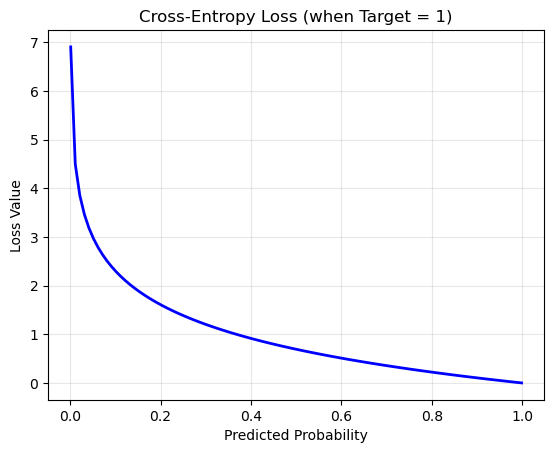

In [13]:
# Generate predictions ranging between 0 to 1
p_range = np.linspace(0.001, 0.999, 100)
# Calculate loss assuming the true label is 1
loss_y1 = -np.log(p_range)

plt.plot(p_range, loss_y1, color='blue', lw=2)
plt.title("Cross-Entropy Loss (when Target = 1)")
plt.xlabel("Predicted Probability")
plt.ylabel("Loss Value")
plt.grid(True, alpha=0.3)
plt.show()

This shows that when the model is more confident of its predictions (predicted probability), the cross-entropy loss value is lower.

The next step is to use the cross entropy value in the step size 